In [2]:
import gdspy

import qnldraw.library as qlib
from qnldraw import plot

import qnldraw  

from qnldraw import Chip
from qnldraw import shapes as sh
# Working gdspy 
import gdspy as gp
from qnldraw.paths import CPW

from qnldraw import Params, paths
from qnldraw.paths import Trace, CPW

import numpy as np

In [3]:
# Create the Chip quickstart
chip = Chip()

# Create a launch component
launch = qlib.Launch(
    cpw={'width': 20, 'gap': 10},
    bondpad={'width': 125, 'length': 125, 'gap': 56.5},
    taper_length=100
)
# Place a launch at x = -4850
launch1 = launch.place((-4500, 0))
# Draw a CPW trace from x = -4500 to x = 4500
cpw = CPW(**launch.get_params()['cpw'], start=launch1.node('cpw')).segment(9000)
# Place a launch at x = 4500
launch2 = launch.place(cpw.current_position(), mirror='y')

# Draw a qubit
qubit = qlib.FloatingPads(
    pads={'x': 135, 'y': 545},
    cutout={'x': 545, 'y': 745},
    spacing=65
).place((0, -50), 'cutout_right', rotation=0)

# chip.add_component([launch1, launch2, cpw], cid='TRANSMISSION_LINE')
chip.add_component(qubit, cid='QUBIT')

lib = gdspy.GdsLibrary()
lib.write_gds('quickstart2.gds', cells=chip.render('MASK', draw_border=True))

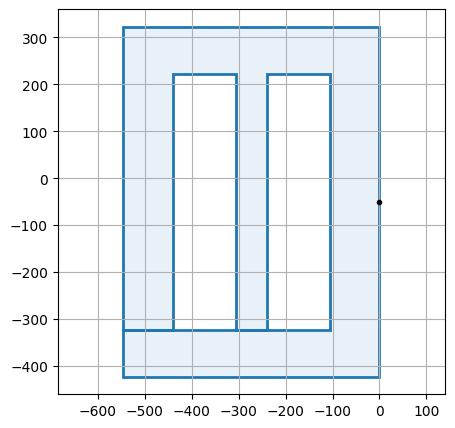

In [4]:

# Plotting the qubit 
fig = plot(qubit)
ax = fig.axes[0]
ax.plot(*qubit.node('cutout_right'), '.k')

In [5]:
qubit.node()

origin,[-272.5 -50. ]
pad1,[-440. -50.]
pad2,[-105. -50.]
pad1_top,[-372.5 222.5]
pad2_top,[-172.5 222.5]
pad1_bottom,[-372.5 -322.5]
pad2_bottom,[-172.5 -322.5]
cutout_left,[-545. -50.]
cutout_right,[ 0. -50.]
cutout_top,[-272.5 322.5]
cutout_bottom,[-272.5 -422.5]


In [6]:
import gdspy
import qnldraw.library as qlib
from qnldraw import plot
from qnldraw import Chip
from qnldraw import shapes as sh
from qnldraw.paths import CPW
from qnldraw import Params, paths
from qnldraw.paths import Trace, CPW
import numpy as np

# Create the Chip
chip = Chip()

# Create a launch component
launch = qlib.Launch(
    cpw={'width': 20, 'gap': 10},
    bondpad={'width': 125, 'length': 125, 'gap': 56.5},
    taper_length=100
)
# Place a launch at x = -4850
launch1 = launch.place((-4500, 0))
# Draw a CPW trace from x = -4500 to x = 4500
cpw = CPW(**launch.get_params()['cpw'], start=launch1.node('cpw')).segment(9000)
# Place a launch at x = 4500
launch2 = launch.place(cpw.current_position(), mirror='y')

# Define positions for four capacitors in a square arrangement
positions = [
    (-200, -200),  # Top-left
    (200, -200),   # Top-right
    (-200, 200),   # Bottom-left
    (200, 200)     # Bottom-right
]

# Create and place four capacitors
capacitors = []
for pos in positions:
    capacitor = qlib.FloatingPads(
        pads={'x': 135, 'y': 545},
        cutout={'x': 545, 'y': 745},
        spacing=65
    ).place(pos, 'cutout_right', rotation=0)
    capacitors.append(capacitor)

# Add all components to the chip
# chip.add_component([launch1, launch2, cpw], cid='TRANSMISSION_LINE')
for idx, capacitor in enumerate(capacitors):
    chip.add_component(capacitor, cid=f'CAPACITOR_{idx+1}')

# Render the chip
lib = gdspy.GdsLibrary()
lib.write_gds('square_capacitors.gds', cells=chip.render('MASK', draw_border=True))


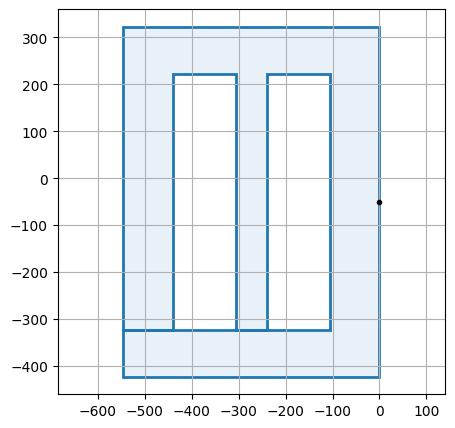

In [7]:

# Plotting the qubit 
fig = plot(qubit)
ax = fig.axes[0]
ax.plot(*qubit.node('cutout_right'), '.k')

In [8]:
import gdspy
import qnldraw.library as qlib
from qnldraw import plot
from qnldraw import Chip
from qnldraw import shapes as sh
from qnldraw.paths import CPW
from qnldraw import Params, paths
from qnldraw.paths import Trace, CPW
import numpy as np

# Create the Chip
chip = Chip()

# Create a launch component
launch = qlib.Launch(
    cpw={'width': 20, 'gap': 10},
    bondpad={'width': 125, 'length': 125, 'gap': 56.5},
    taper_length=100
)

# Define positions for four launches in a square arrangement
launch_positions = [
    (-4500, -4500),  # Bottom-left
    (4500, -4500),   # Bottom-right
    (-4500, 4500),   # Top-left
    (4500, 4500)     # Top-right
]

# Place the launches at the defined positions
launches = []
for pos in launch_positions:
    launch_placed = launch.place(pos)
    launches.append(launch_placed)

# Define positions for four capacitors in a square arrangement
capacitor_positions = [
    (-200, -200),  # Bottom-left
    (200, -200),   # Bottom-right
    (-200, 200),   # Top-left
    (200, 200)     # Top-right
]

# Create and place four capacitors
capacitors = []
for pos in capacitor_positions:
    capacitor = qlib.FloatingPads(
        pads={'x': 50, 'y': 50},
        cutout={'x': 545, 'y': 745},
        spacing=65
    ).place(pos, 'cutout_right', rotation=0)
    capacitors.append(capacitor)

# Add all components to the chip
for idx, launch in enumerate(launches):
    chip.add_component(launch, cid=f'LAUNCH_{idx+1}')

for idx, capacitor in enumerate(capacitors):
    chip.add_component(capacitor, cid=f'CAPACITOR_{idx+1}')

# Render the chip
lib = gdspy.GdsLibrary()
lib.write_gds('square_capacitors_with_launches.gds', cells=chip.render('MASK', draw_border=True))


In [9]:
import gdspy
import qnldraw.library as qlib
from qnldraw import plot
from qnldraw import Chip
from qnldraw import shapes as sh
from qnldraw.paths import CPW
from qnldraw import Params, paths
from qnldraw.paths import Trace, CPW
import numpy as np

# Create the Chip
chip = Chip()

# Create a launch component
launch = qlib.Launch(
    cpw={'width': 20, 'gap': 10},
    bondpad={'width': 125, 'length': 125, 'gap': 56.5},
    taper_length=100
)

# Define positions for four launches in a square arrangement
launch_positions = [
    (-4500, -4500),  # Bottom-left
    (4500, -4500),   # Bottom-right
    (-4500, 4500),   # Top-left
    (4500, 4500)     # Top-right
]

# Place the launches at the defined positions
launches = []
for pos in launch_positions:
    launch_placed = launch.place(pos)
    launches.append(launch_placed)

# Define positions for four capacitors in a square arrangement
capacitor_positions = [
    (-200, -100),  # Bottom
    (-200, 100),   # Top
]

# Create and place four capacitors
capacitors = []
for pos in capacitor_positions:
    capacitor = qlib.FloatingPads(
        pads={'x': 50, 'y': 50},
        cutout={'x': 545, 'y': 745},
        spacing=15
    ).place(pos, 'cutout_right', rotation=0)
    capacitors.append(capacitor)

# Add all components to the chip
for idx, launch in enumerate(launches):
    chip.add_component(launch, cid=f'LAUNCH_{idx+1}')

for idx, capacitor in enumerate(capacitors):
    chip.add_component(capacitor, cid=f'CAPACITOR_{idx+1}')

# Render the chip
lib = gdspy.GdsLibrary()
lib.write_gds('square_capacitors_with_launches.gds', cells=chip.render('MASK', draw_border=True))


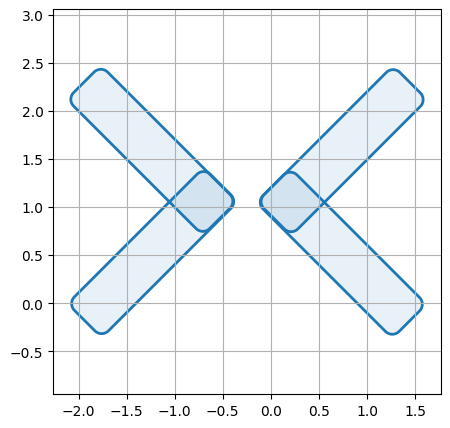

In [10]:
import gdspy

import qnldraw.library as qlib
from qnldraw import plot

import qnldraw  

from qnldraw import Chip



from qnldraw import shapes as sh
# Working gdspy 
import gdspy as gp
from qnldraw.paths import CPW

from qnldraw import Params, paths
from qnldraw.paths import Trace, CPW

import numpy as np
# g_bL = 
# g_TR = 
# ground=gdspy.Rectangle(point1=[lx,1],point2=[0.5,3]).fillet(radius=[0.1])

rec1=gdspy.Rectangle(point1=[0,1],point2=[0.5,3]).fillet(radius=[0.1])
rec1.rotate(-np.pi/4).translate(-2.82,-0.71)
gap = 0.9
rec2=gdspy.Rectangle(point1=[0,1],point2=[0.5,3]).fillet(radius=[0.1])
rec2.rotate(-np.pi/4).translate(-1.75+gap, 0.350)


rec3=gdspy.Rectangle(point1=[0,1],point2=[0.5,3]).fillet(radius=[0.1])
rec3.rotate(np.pi/4).translate(0,0)

rec4=gdspy.Rectangle(point1=[0,1],point2=[0.5,3]).fillet(radius=[0.1])
rec4.rotate(np.pi/4).translate(1.07+gap, -1.07)


# def calculate_centroid(rectangle):
#     # Get the four corners of the rectangle
#     corners = rectangle.get_bounding_box()
#     centroid_x = (corners[0, 0] + corners[1, 0]) / 2
#     centroid_y = (corners[0, 1] + corners[1, 1]) / 2
#     return np.array([centroid_x, centroid_y])

# # Calculate the centroids of rec1 and mirror_rec1 (or rec2 and mirror_rec2 if preferred)
# centroid1 = calculate_centroid(rec1)
# centroid2 = calculate_centroid(mirror_rec1)

# # Calculate the midpoint between the centroids
# midpoint = (centroid1 + centroid2) / 2
# print(f"Midpoint between the two mirrored structures: {midpoint}")

fig = plot([rec1, rec2, rec3, rec4])


/Users/devaldeliwala/QNLDraw/qnldraw/chip.py:271: UserWarning: [QNLDraw] component with ID QUBIT already exists,renaming component with ID 0f717eaa305a43c6a55c5e83ac456a28
  warnings.warn(


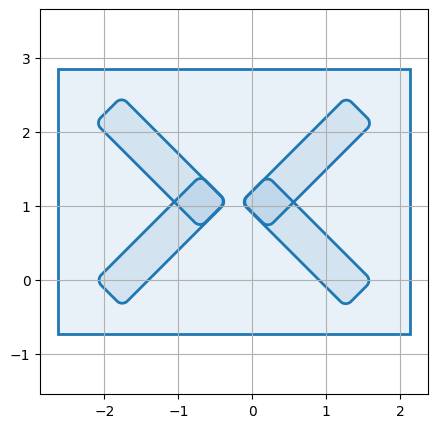

In [4]:
import gdspy

import qnldraw.library as qlib
from qnldraw import plot

import qnldraw  

from qnldraw import Chip



from qnldraw import shapes as sh
# Working gdspy 
import gdspy as gp
from qnldraw.paths import CPW

from qnldraw import Params, paths
from qnldraw.paths import Trace, CPW

import numpy as np
chip = Chip()

# Define the original and mirrored rectangles
rec1 = gdspy.Rectangle(point1=[0, 1], point2=[0.5, 3]).fillet(radius=[0.1])
rec1.rotate(-np.pi/4).translate(-2.82, -0.71)

rec2 = gdspy.Rectangle(point1=[0, 1], point2=[0.5, 3]).fillet(radius=[0.1])
rec2.rotate(-np.pi/4).translate(-1.75 + 0.9, 0.350)

rec3 = gdspy.Rectangle(point1=[0, 1], point2=[0.5, 3]).fillet(radius=[0.1])
rec3.rotate(np.pi/4).translate(0, 0)

rec4 = gdspy.Rectangle(point1=[0, 1], point2=[0.5, 3]).fillet(radius=[0.1])
rec4.rotate(np.pi/4).translate(1.07 + 0.9, -1.07)

# Function to calculate the bounding box of the entire structure
def calculate_bounding_box(elements):
    all_x = []
    all_y = []
    
    for element in elements:
        bbox = element.get_bounding_box()
        all_x.extend([bbox[0, 0], bbox[1, 0]])
        all_y.extend([bbox[0, 1], bbox[1, 1]])
    
    min_x, max_x = min(all_x), max(all_x)
    min_y, max_y = min(all_y), max(all_y)
    
    return min_x, min_y, max_x, max_y

# Calculate the bounding box of the entire structure
min_x, min_y, max_x, max_y = calculate_bounding_box([rec1, rec2, rec3, rec4])

# Calculate the midpoint of the bounding box
midpoint_x = (min_x + max_x) / 2
midpoint_y = (min_y + max_y) / 2
midpoint = np.array([midpoint_x, midpoint_y])

# Define the scale factor or padding (adjust as needed)
scale_factor = 1.3  # Increase the size by 20%

# Calculate the size of the encapsulating rectangle
encapsulating_width = (max_x - min_x) * scale_factor
encapsulating_height = (max_y - min_y) * scale_factor

# Define the encapsulating rectangle with the same center as the midpoint
encapsulating_rec = gdspy.Rectangle(
    point1=[midpoint_x - encapsulating_width / 2, midpoint_y - encapsulating_height / 2],
    point2=[midpoint_x + encapsulating_width / 2, midpoint_y + encapsulating_height / 2]
)

# Plot the original structures and the encapsulating rectangle
fig = plot([rec1, rec2, rec3, rec4, encapsulating_rec])
chip.add_component([rec1, rec2, rec3, rec4, encapsulating_rec], cid='QUBIT')
chip.add_component(rec1, cid='QUBIT')

lib = gdspy.GdsLibrary()
lib.write_gds('test.gds', cells=chip.render('MASK', draw_border=True))

In [12]:
import gdspy

import qnldraw.library as qlib
from qnldraw import plot

import qnldraw  

from qnldraw import Chip



from qnldraw import shapes as sh
# Working gdspy 
import gdspy as gp
from qnldraw.paths import CPW

from qnldraw import Params, paths
from qnldraw.paths import Trace, CPW

import numpy as np

In [13]:
import gdspy
import numpy as np

class Cutout:
    def __init__(self, rectangles, scale_factor=1.3):
        self.rectangles = rectangles
        self.scale_factor = scale_factor
        self.cutout = None

    def calculate_bounding_box(self):
        all_x = []
        all_y = []
        
        for element in self.rectangles:
            bbox = element.get_bounding_box()
            all_x.extend([bbox[0, 0], bbox[1, 0]])
            all_y.extend([bbox[0, 1], bbox[1, 1]])
        
        min_x, max_x = min(all_x), max(all_x)
        min_y, max_y = min(all_y), max(all_y)
        
        return min_x, min_y, max_x, max_y

    def create_encapsulating_rectangle(self):
        min_x, min_y, max_x, max_y = self.calculate_bounding_box()

        midpoint_x = (min_x + max_x) / 2
        midpoint_y = (min_y + max_y) / 2

        encapsulating_width = (max_x - min_x) * self.scale_factor
        encapsulating_height = (max_y - min_y) * self.scale_factor

        encapsulating_rec = gdspy.Rectangle(
            point1=[midpoint_x - encapsulating_width / 2, midpoint_y - encapsulating_height / 2],
            point2=[midpoint_x + encapsulating_width / 2, midpoint_y + encapsulating_height / 2]
        )

        return encapsulating_rec

    def perform_subtraction(self):
        encapsulating_rec = self.create_encapsulating_rectangle()
        self.cutout = gdspy.boolean(
            encapsulating_rec, 
            self.rectangles, 
            operation='not'  # Subtract the rectangles from the encapsulating_rec
        )
        return self.cutout

    def place(self, position=(0, 0)):
        if self.cutout is None:
            self.perform_subtraction()
        return self.cutout.translate(*position)


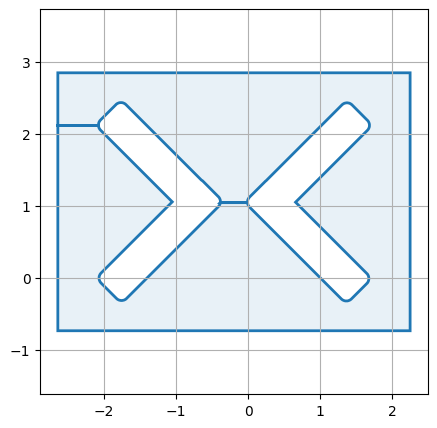

In [14]:
import gdspy
import numpy as np
from qnldraw import plot
from qnldraw import Chip

# chip = Chip()
gap = 1

# Define the original and mirrored rectangles
rec1 = gdspy.Rectangle(point1=[0, 1], point2=[0.5, 3]).fillet(radius=[0.1])
rec1.rotate(-np.pi/4).translate(-2.82, -0.71)

rec2 = gdspy.Rectangle(point1=[0, 1], point2=[0.5, 3]).fillet(radius=[0.1])
rec2.rotate(-np.pi/4).translate(-1.75 + gap , 0.350)

rec3 = gdspy.Rectangle(point1=[0, 1], point2=[0.5, 3]).fillet(radius=[0.1])
rec3.rotate(np.pi/4).translate(0, 0)

rec4 = gdspy.Rectangle(point1=[0, 1], point2=[0.5, 3]).fillet(radius=[0.1])
rec4.rotate(np.pi/4).translate(1.07 + gap , -1.07)

# Function to calculate the bounding box of the entire structure
def calculate_bounding_box(elements):
    all_x = []
    all_y = []
    
    for element in elements:
        bbox = element.get_bounding_box()
        all_x.extend([bbox[0, 0], bbox[1, 0]])
        all_y.extend([bbox[0, 1], bbox[1, 1]])
    
    min_x, max_x = min(all_x), max(all_x)
    min_y, max_y = min(all_y), max(all_y)
    
    return min_x, min_y, max_x, max_y

# Calculate the bounding box of the entire structure
min_x, min_y, max_x, max_y = calculate_bounding_box([rec1, rec2, rec3, rec4])

# Calculate the midpoint of the bounding box
midpoint_x = (min_x + max_x) / 2
midpoint_y = (min_y + max_y) / 2
midpoint = np.array([midpoint_x, midpoint_y])

# Define the scale factor or padding (adjust as needed)
scale_factor = 1.3  # Increase the size by 30%

# Calculate the size of the encapsulating rectangle
encapsulating_width = (max_x - min_x) * scale_factor
encapsulating_height = (max_y - min_y) * scale_factor

# Define the encapsulating rectangle with the same center as the midpoint
encapsulating_rec = gdspy.Rectangle(
    point1=[midpoint_x - encapsulating_width / 2, midpoint_y - encapsulating_height / 2],
    point2=[midpoint_x + encapsulating_width / 2, midpoint_y + encapsulating_height / 2]
)

# Perform the boolean subtraction
cutout = gdspy.boolean(
    encapsulating_rec, 
    [rec1, rec2, rec3, rec4], 
    operation='not'  # Subtract rec1, rec2, rec3, rec4 from encapsulating_rec
)

# Plot the result
fig = plot([cutout])

# # Add the resulting cutout to the chip
# chip.add(cutout, cid='QUBIT')
# chip.
# chip.add_component(rec1, cid='test')
# # Save to a GDS file
# lib = gdspy.GdsLibrary()
# lib.write_gds('test1.gds', cells=chip.render('MASK', draw_border=True))


Design saved as 'antenna_cutout.gds'


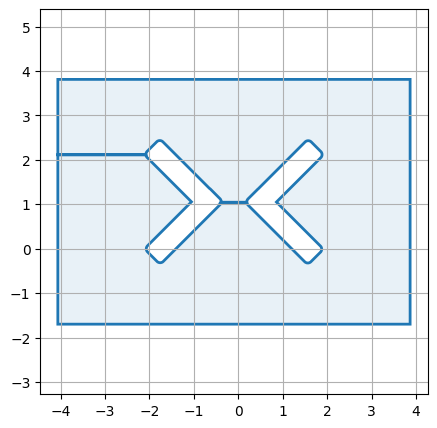

In [15]:
import gdspy
import numpy as np
from qnldraw import plot
from qnldraw import Chip

gap = 1.2
# Define the original rectangles
rec1 = gdspy.Rectangle(point1=[0, 1], point2=[0.5, 3]).fillet(radius=[0.1])
rec1.rotate(-np.pi/4).translate(-2.82, -0.71)

rec2 = gdspy.Rectangle(point1=[0, 1], point2=[0.5, 3]).fillet(radius=[0.1])
rec2.rotate(-np.pi/4).translate(-1.75 + gap, 0.350)

rec3 = gdspy.Rectangle(point1=[0, 1], point2=[0.5, 3]).fillet(radius=[0.1])
rec3.rotate(np.pi/4).translate(0, 0)

rec4 = gdspy.Rectangle(point1=[0, 1], point2=[0.5, 3]).fillet(radius=[0.1])
rec4.rotate(np.pi/4).translate(1.07 + gap, -1.07)

# Combine the four rectangles into a single element
combined_rectangles = gdspy.boolean([rec1, rec2, rec3, rec4], [], operation='or')

# Function to calculate the bounding box of the entire structure
def calculate_bounding_box(element):
    bbox = element.get_bounding_box()
    min_x, max_x = bbox[:, 0].min(), bbox[:, 0].max()
    min_y, max_y = bbox[:, 1].min(), bbox[:, 1].max()
    return min_x, min_y, max_x, max_y

# Calculate the bounding box of the combined structure
min_x, min_y, max_x, max_y = calculate_bounding_box(combined_rectangles)

# Calculate the midpoint of the bounding box
midpoint_x = (min_x + max_x) / 2
midpoint_y = (min_y + max_y) / 2

# Define the scale factor or padding (adjust as needed)
scale_factor = 2  # Increase the size by 30%

# Calculate the size of the encapsulating rectangle
encapsulating_width = (max_x - min_x) * scale_factor
encapsulating_height = (max_y - min_y) * scale_factor

# Define the encapsulating rectangle with the same center as the midpoint
encapsulating_rec = gdspy.Rectangle(
    point1=[midpoint_x - encapsulating_width / 2, midpoint_y - encapsulating_height / 2],
    point2=[midpoint_x + encapsulating_width / 2, midpoint_y + encapsulating_height / 2]
)

# Perform the boolean subtraction
cutout = gdspy.boolean(
    encapsulating_rec, 
    combined_rectangles, 
    operation='not'  # Subtract the combined rectangles from the encapsulating rectangle
)

# Plot the result
fig = plot([cutout])

# Optional: Add the resulting cutout to the chip (uncomment if using qnldraw Chip)
# chip = Chip()
# chip.add(cutout, cid='QUBIT')
# chip.add_component(combined_rectangles, cid='test')

# Optional: Save to a GDS file (uncomment if needed)
# lib = gdspy.GdsLibrary()
# lib.write_gds('test1.gds', cells=chip.render('MASK', draw_border=True))
lib = gdspy.GdsLibrary()

# Create a cell in the GDS library to hold the design
cell = lib.new_cell('ANTENNA_CUTOUT_1')

# Add the cutout to the cell
cell.add(cutout)

# Save the GDS file
lib.write_gds('antenna_cutout_gap1.2.gds')

print("Design saved as 'antenna_cutout.gds'")

Design saved as 'antenna_cutout.gds'


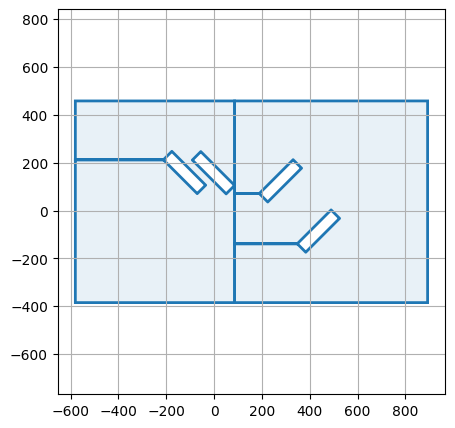

In [16]:
import gdspy
import numpy as np
from qnldraw import plot
from qnldraw import Chip

gap = 120
# Define the original rectangles
rec1 = gdspy.Rectangle(point1=[0, 100], point2=[50, 300]).fillet(radius=[0.1])
rec1.rotate(-np.pi/4).translate(280-2.82, -209-0.71)

rec2 = gdspy.Rectangle(point1=[0, 100], point2=[50, 300]).fillet(radius=[0.1])
rec2.rotate(-np.pi/4).translate(-1.75 + gap, 0.350)

rec3 = gdspy.Rectangle(point1=[0, 100], point2=[50, 300]).fillet(radius=[0.1])
rec3.rotate(np.pi/4).translate(0, 0)

rec4 = gdspy.Rectangle(point1=[0, 100], point2=[50, 300]).fillet(radius=[0.1])
rec4.rotate(np.pi/4).translate(1.07 + gap, -1.07)

# Combine the four rectangles into a single element
combined_rectangles = gdspy.boolean([rec1, rec2, rec3, rec4], [], operation='or')

# Function to calculate the bounding box of the entire structure
def calculate_bounding_box(element):
    bbox = element.get_bounding_box()
    min_x, max_x = bbox[:, 0].min(), bbox[:, 0].max()
    min_y, max_y = bbox[:, 1].min(), bbox[:, 1].max()
    return min_x, min_y, max_x, max_y

# Calculate the bounding box of the combined structure
min_x, min_y, max_x, max_y = calculate_bounding_box(combined_rectangles)

# Calculate the midpoint of the bounding box
midpoint_x = (min_x + max_x) / 2
midpoint_y = (min_y + max_y) / 2

# Define the scale factor or padding (adjust as needed)
scale_factor = 2  # Increase the size by 30%

# Calculate the size of the encapsulating rectangle
encapsulating_width = (max_x - min_x) * scale_factor
encapsulating_height = (max_y - min_y) * scale_factor

# Define the encapsulating rectangle with the same center as the midpoint
encapsulating_rec = gdspy.Rectangle(
    point1=[midpoint_x - encapsulating_width / 2, midpoint_y - encapsulating_height / 2],
    point2=[midpoint_x + encapsulating_width / 2, midpoint_y + encapsulating_height / 2]
)

# Perform the boolean subtraction
cutout = gdspy.boolean(
    encapsulating_rec, 
    combined_rectangles, 
    operation='not'  # Subtract the combined rectangles from the encapsulating rectangle
)

# Plot the result
fig = plot([cutout])

# Optional: Add the resulting cutout to the chip (uncomment if using qnldraw Chip)
# chip = Chip()
# chip.add(cutout, cid='QUBIT')
# chip.add_component(combined_rectangles, cid='test')

# Optional: Save to a GDS file (uncomment if needed)
# lib = gdspy.GdsLibrary()
# lib.write_gds('test1.gds', cells=chip.render('MASK', draw_border=True))
lib = gdspy.GdsLibrary()

# Create a cell in the GDS library to hold the design
cell = lib.new_cell('ANTENNA_CUTOUT_4')

# Add the cutout to the cell
cell.add(cutout)

# Save the GDS file
lib.write_gds('antenna_cutout_gap3.gds')

print("Design saved as 'antenna_cutout.gds'")

In [17]:
import numpy as np
import scipy.constants as cs
from matplotlib import pyplot as plt
from qutip import *
import sys
# Here, configure the path to the directory for pre-defined functions.
sys.path.append('/Users/zpedramrazi/Documents/QNL/github/Fluxonium_berkeley-main/')
from Fluxonium_hamiltonians import Single_small_junction as fluxonium
import plotting_settings
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400

ModuleNotFoundError: No module named 'Fluxonium_hamiltonians'